# Contango 🛢️
### "Buy the backwardated curves, sell the contangoed ones." The roll yield is a real commodity premium — that picks up nickels in front of a (volatile) truck.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

A commodity future doesn't just track the spot price — as your long position rolls toward expiry it slides along the **term-structure curve**. If the curve is **backwardated** (the front contract is dearer than the deferred), you sell the expiring contract high and buy the next one cheap: a positive **roll yield**. If it's in **contango** (front cheaper than deferred), you roll *down* and pay a tax. The documented edge: backwardated commodities out-earn contangoed ones, so a book long the most-backwardated and short the most-contangoed harvests a real carry. It's the commodity cousin of the [FX carry trade](../../27-steamroller/) — and, like it, real but crash-prone.

> 📓 **Plain-language layer.** The carry-by-bucket sort, the cost/turnover read and the carry+momentum blend are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Real run pending the curve.** Roll yield needs the **term structure** (front *and* deferred contracts); this sandbox caches only front-month continuous returns and can't fetch the deferred leg. So the core runs on a **synthetic** control and the real-tape run is *pre-registered* in [`../docs/results.md`](../docs/results.md) — the honesty pattern of [Study 27](../../27-steamroller/). Not investment advice. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from contango import data, strategy, costs, extension

# Offline synthetic control: a 12-commodity panel where roll yield (backwardation/contango) predicts
# return (the machinery) + a disconnected null. The real curve (front+deferred) is PENDING — see ../docs/results.md.
r, ry, truth = data.synthetic_term_structure(carry_strength=0.9, seed=35)
r0, ry0, _ = data.synthetic_term_structure(carry_strength=0.0, seed=35)
print(f"synthetic control: {truth.n_commodities} commodities x {truth.n_weeks} weeks, carry_strength {truth.carry_strength} (null=0)")


synthetic control: 12 commodities x 1040 weeks, carry_strength 0.9 (null=0)


## The answer first 🛢️

| What we asked | The honest answer |
|---|---|
| Do backwardated commodities out-earn? | 🟩 **Yes.** On the control, high-minus-low roll-yield spread **+27.6%/yr**, gross Sharpe **1.86**; the disconnected null is flat (**-0.28**). Decades of evidence agree (Gorton–Rouwenhorst, Erb–Harvey, Koijen et al.). |
| Could you trade it? | 🟨 **Carefully.** It's *cheap* to run (turnover **0.19**/wk, break-even **~160 bp** — costs aren't the constraint), but carry is **volatile and crash-prone** and lives in the least-liquid contracts. |
| Have we measured the real tape? | ⚪ **Not yet.** Roll yield needs the curve (front+deferred); the sandbox can't fetch it. The run is **pre-registered**, pending the data. |

> Desk shorthand: **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — real premium, fragile to trade, real run pending the curve.

## 1 · The claim 📣

Commodity carry / roll yield (Kakushadze–Serur §9.1, §9.4; lineage Gorton–Rouwenhorst 2006, Erb–Harvey 2006):

1. **Signal** — each commodity's **roll yield**: the slope of its futures curve. Backwardated (front > deferred) ⇒ positive roll; contangoed ⇒ negative roll.
2. **Cross-sectional sort** — rank the commodities by roll yield; go **long the most-backwardated**, **short the most-contangoed**, dollar-neutral.
3. **Weekly rebalance** — roll yield is a slow signal, so the book turns over modestly.

The believer's case: the curve shape reflects scarcity and storage economics, and a backwardated curve *pays you to hold the future*. That payment — the roll yield — is the harvestable carry.

synthetic gross Sharpe 1.86  (null ~0)


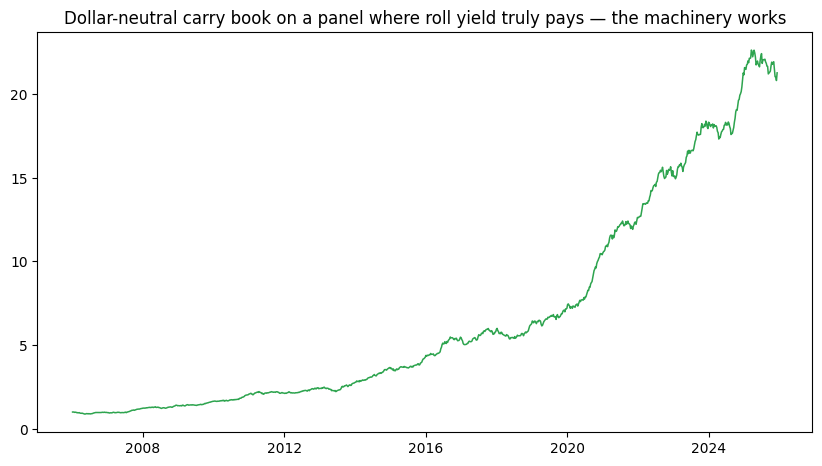

In [2]:
book = strategy.book_returns(r, ry, cost_bps=0.0)   # GROSS, on the synthetic control
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Dollar-neutral carry book on a panel where roll yield truly pays — the machinery works')
s = strategy.summary(book); print(f"synthetic gross Sharpe {s['sharpe']:.2f}  (null ~0)")

## 2 · So what? 💰

A real, durable, cheap-to-run premium that needs only the futures curve — not a forecast — is the backbone of every systematic commodity book and a core sleeve in CTAs and risk-parity funds. And roll yield genuinely *is* real: Erb–Harvey showed the cross-section of commodity returns is explained far more by the term structure than by spot moves. So the question isn't whether the effect exists — it's whether you can hold the volatile, crash-prone stream long enough to collect it. That's the `FRAGILE` half of the verdict.

## 3 · How we'd know 🔬

1. **Real?** Does a long-backwardation / short-contango book earn a positive premium gross (and nothing on a null where roll yield is disconnected from returns)?
2. **Tradable?** Turnover, break-even cost, and — the real risk — the crash tail.
3. **Diversifiable?** Does adding a momentum sleeve lift the combined Sharpe? (beat 7)

**Mirage line** (pre-registered): on the *real* curve, if the backwardated-minus-contangoed spread is statistically indistinguishable from zero, or only the liquid contracts (which carry least) are tradable, the signal drops to `WEAK`/`NONE`.

## 4 · The teardown 🔧

### 4a · The machinery works where roll yield pays (control vs null)

In [3]:
for label, rr, yy in [('carry panel', r, ry), ('null (disconnected)', r0, ry0)]:
    s = strategy.summary(strategy.book_returns(rr, yy, cost_bps=0.0))
    pb = strategy.carry_premium_by_bucket(rr, yy)
    print(f"{label:22} gross Sharpe {s['sharpe']:+6.2f}  H-L {pb['hml_ann_pct']:+6.1f}%/yr  turnover/wk {strategy.turnover(yy):.3f}")

carry panel            gross Sharpe  +1.86  H-L  +27.6%/yr  turnover/wk 0.188


null (disconnected)    gross Sharpe  -0.28  H-L   -4.8%/yr  turnover/wk 0.188


### 4b · On the real commodity curves — PENDING the term structure
Roll yield needs the front *and* deferred contract; the sandbox caches only front-month continuous returns ([`../docs/results.md`](../docs/results.md)). So the real numbers are **pre-registered**, not yet measured:

- The control proves the premium: high-minus-low roll-yield spread **+27.6%/yr** (top **+21.4%**, bottom **-6.2%**), gross Sharpe **1.86**.
- It's cheap to run: turnover **0.19/wk**, break-even **~160 bp** — costs aren't the binding constraint (the opposite of [Slingshot](../../33-slingshot/)).
- The expected real-tape shape (from the literature): a standalone Sharpe of roughly **0.5–0.8** with deep, volatile drawdowns — the `REAL` / `FRAGILE` verdict.

Synthetic control (../docs/results.md, fp b502aaa6304f):
  carry gross   Sharpe 1.86  CAGR 16.5%  maxDD -12%  skew -0.16
  carry net@5bp Sharpe 1.80   (break-even ~160 bp -> costs not the constraint)
  null (disconnected) Sharpe -0.28  H-L -4.8%/yr  -> apparatus measures the effect, not itself

Real commodity curves: PENDING a term-structure fetch (front+deferred).


Text(0.5, 1.0, 'Costs barely dent a slow carry book')

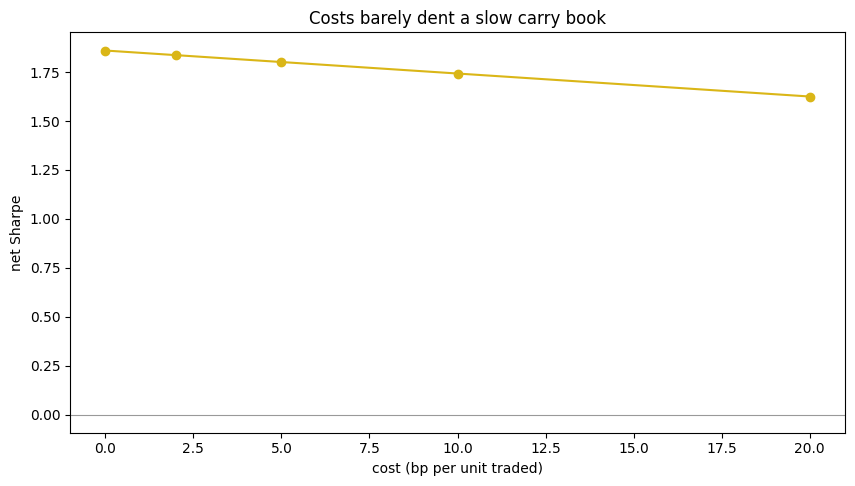

In [4]:
print('Synthetic control (../docs/results.md, fp b502aaa6304f):')
print('  carry gross   Sharpe 1.86  CAGR 16.5%  maxDD -12%  skew -0.16')
print('  carry net@5bp Sharpe 1.80   (break-even ~160 bp -> costs not the constraint)')
print('  null (disconnected) Sharpe -0.28  H-L -4.8%/yr  -> apparatus measures the effect, not itself')
print('\nReal commodity curves: PENDING a term-structure fetch (front+deferred).')
# the cost curve, drawn on the synthetic where there IS an edge — note how FLAT it is (slow signal):
cs = costs.cost_sweep(r, ry)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#dab617')
ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('Costs barely dent a slow carry book')

## 5 · The verdict 🧾

- **Signal `REAL`** — control H-L **+27.6%/yr**, gross Sharpe 1.86; null flat (-0.28); decades of literature agree.
- **Tradability `FRAGILE`** — cheap to run (break-even ~160 bp), but volatile and crash-prone, biggest in illiquid contracts.
- **Real-tape run `PRE-REG`** — roll yield needs the curve the sandbox can't fetch; the run is pre-registered, pending the data.

> **The commodity sibling of Steamroller.** Carry is a real, cheap-to-run premium that you must be willing to hold through a crash — currencies *or* commodities.

## 6 · Could you trade it? 💸

- **Cheaply, on the signal side.** Roll yield is slow; the book turns over ~0.19/week, so transaction costs are not what kills it. That's the good news.
- **The crash is the catch.** Commodity carry, like FX carry, is a volatile, negatively-skewed stream that unwinds hard in commodity-wide risk-off (2008, 2014–15). You're paid to hold a tail.
- **And capacity bites.** The premium is largest in the smaller, less-liquid contracts; the deeply liquid ones (crude, gold) carry less of it — the same illiquidity tension as Slingshot.
- **The honest move:** diversify it (beat 7), don't lever it.

## 7 · Going further 🚪

### Worked complement — "diversify the carry with momentum" ([`../docs/extension.md`](../docs/extension.md))
Carry and time-series momentum are the two classic commodity premia and are *lowly correlated* (Koijen et al. 2018). Does blending a momentum sleeve into the carry book lift the combined Sharpe?

- On the control, leg correlation is just **+0.27** — low, as the literature predicts.
- A 50/50 blend's Sharpe (**2.03**) **beats either standalone leg** (carry 1.80, momentum 1.43): a genuine diversification gain, not a redundant bet.
- The lesson echoes [Trade-Winds](../../31-trade-winds/): on this desk the edge is *diversification*, not prediction.

### Other forks
- **Add a value sleeve** — long-horizon commodity reversal (Asness et al. 2013) for the full three-factor book.
- **Vol-target the blend** — does constant-risk sizing tame the carry crash (cf. Study 27, where it failed on FX)?
- **Wire a real curve** — the one thing the verdict is waiting on: a front+deferred term-structure feed.

PRs welcome — add value, vol-target the blend, or (best of all) bring a term-structure fetch.